Data overview, target analysis, temporal exploration, behavioral analysis
before churn (prediction-window justification), and feature relationships.

Logic lives in `src/churn/eda/`; this notebook calls it and adds interpretation.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from churn.config import INTERIM_DIR
from churn.eda.overview import run_overview
from churn.eda.target_analysis import run_target_analysis, churn_rate_by_tenure, churn_rate_by_age_bucket
from churn.eda.temporal import run_temporal_analysis, explore_inactivity_vs_reference
from churn.eda.behavioral import run_behavioral_analysis
from churn.eda.correlations import run_correlation_analysis

from pathlib import Path

FIGURES_DIR = Path.cwd().parent / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

def save_fig(fig, name: str):
    fig.savefig(FIGURES_DIR / f"{name}.png", dpi=150, bbox_inches="tight")

subscriber_static = pd.read_parquet(INTERIM_DIR / "subscriber_static.parquet")
monthly_usage = pd.read_parquet(INTERIM_DIR / "monthly_usage.parquet")

## 1. Data overview

In [2]:
run_overview(subscriber_static, monthly_usage)


=== subscriber_static: shape=(423766, 22) ===
churn                                   object
classe_anciennete                       object
subscriber_id                            int64
msisdn                                  object
sales_channel_description              float64
date_activation                 datetime64[ns]
churn_date                      datetime64[ns]
first_call_date                 datetime64[ns]
last_call_date                  datetime64[ns]
first_recharge_date             datetime64[ns]
first_recharge_amount                  float64
last_international_call_date    datetime64[ns]
original_operator                       object
dat_attrib_kridi                datetime64[ns]
dat_remb_kridi_net              datetime64[ns]
ported_in_request_date          datetime64[ns]
is_churn                                  bool
age                                    float64
marital_status                          object
gender                                  object
customer_lang


--- monthly_usage: missingness ---
                         n_missing  pct_missing
device_type                  24166         0.91
flag_smartphone              24166         0.91
number_of_reactivations          1         0.00

--- subscriber_static: key numeric variable distributions ---
        count       mean        std  min    1%   25%   50%   75%   99%    max
age  403083.0  43.160277  14.452083  0.0  19.0  32.0  42.0  54.0  80.0  100.0

--- monthly_usage: key numeric variable distributions ---


                        count          mean           std  min   1%  25%  \
recharge_amount     2668258.0  9.100415e+03  2.355892e+04  0.0  0.0  0.0   
mou_onnet           2668258.0  5.152079e+03  1.500426e+04  0.0  0.0  0.0   
data_trafic_volume  2668258.0  1.039364e+10  3.791813e+10  0.0  0.0  0.0   

                          50%           75%           99%           max  
recharge_amount        1000.0  1.000000e+04  8.300000e+04  7.098302e+06  
mou_onnet               360.0  4.128000e+03  6.652243e+04  8.682810e+05  
data_trafic_volume  1585875.5  4.519031e+09  1.387869e+11  2.272043e+12  

--- subscriber_static: duplicate check on key=['subscriber_id'] ---
  duplicate rows: 0 (expected 0)



--- monthly_usage: duplicate check on key=['subscriber_id', 'period_date'] ---
  duplicate rows: 0 (expected 0)


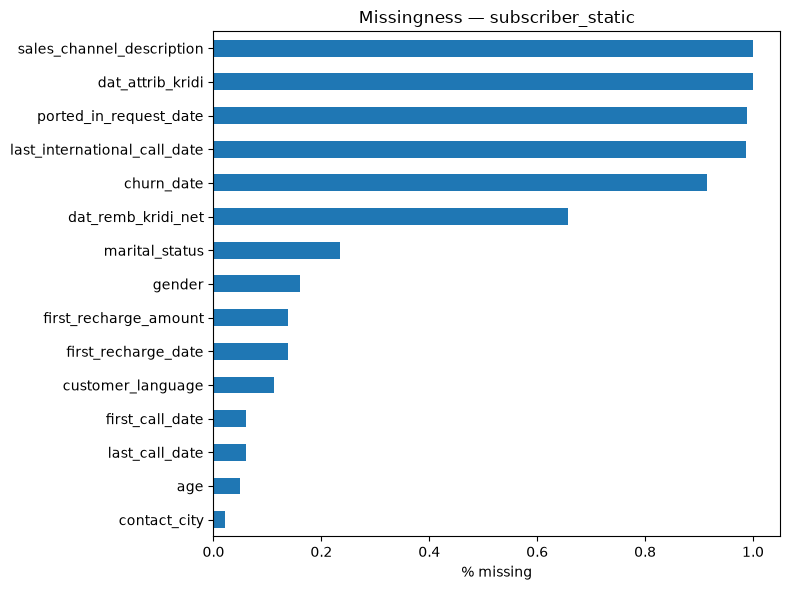

In [3]:
missingness = subscriber_static.isna().mean().sort_values(ascending=False)
missingness = missingness[missingness > 0]

fig = plt.figure(figsize=(8, 6))
missingness.plot(kind="barh")
plt.xlabel("% missing")
plt.title("Missingness — subscriber_static")
plt.gca().invert_yaxis()
plt.tight_layout()
save_fig(fig, "01_missingness")
plt.show()

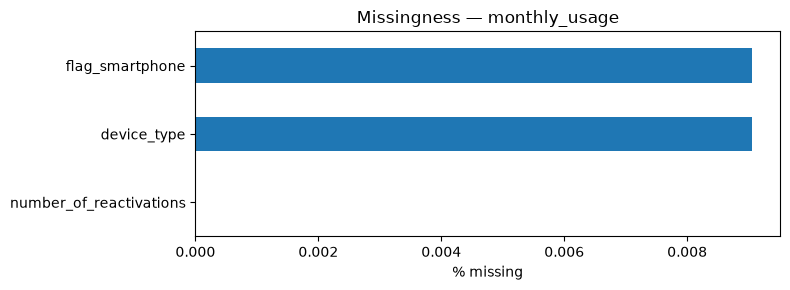

In [4]:
missingness_usage = monthly_usage.isna().mean().sort_values(ascending=False)
missingness_usage = missingness_usage[missingness_usage > 0]

fig = plt.figure(figsize=(8, 3))
missingness_usage.plot(kind="barh")
plt.xlabel("% missing")
plt.title("Missingness — monthly_usage")
plt.gca().invert_yaxis()
plt.tight_layout()
save_fig(fig, "01_missingness_monthly_usage")
plt.show()

**Observations — Data overview**

- **Missing values are consistent with the raw audit.** Most variables have acceptable completeness. The high missing rate for churn_date (91.44%) is expected because it is only considered for subscribers with churn = Yes.
- **Some variables contain little or no usable information.** sales_channel_description and dat_attrib_kridi are almost entirely missing and will be considered for removal during feature selection.  
- **Data cleaning was effective.** Invalid age values were converted to missing values rather than corrected, preserving data integrity.
- **Usage variables are highly right-skewed and contain many zero values.** Many subscribers have little or no activity while a small number are heavy users. This will be taken into account during feature engineering and model preparation.
- **Usage-related missing values have been resolved.** Variables such as data_trafic_volume, total_data_revenu_amount, and total_voice_revenu_amount were filled with zero where they represent genuine periods of no activity.
  

### 1.5 Distribution transformation check (log1p)

The usage variables flagged above as highly right-skewed motivate applying a
`log1p` transform later in feature engineering (`churn.features.snapshot`).
This is a quick illustrative check on the raw data only — computing skew and
plotting before/after histograms for the 3 key usage variables — to confirm
`log1p` actually helps before committing to it downstream. `log1p` is fixed
and parameter-free, so it's safe to compute here on the full raw table
without any train/test leakage concern.

In [5]:
import numpy as np
from churn.eda.overview import compare_log1p_skew, KEY_NUMERIC_VARS

log1p_cols = KEY_NUMERIC_VARS["monthly_usage"]
skew_table = compare_log1p_skew(monthly_usage, log1p_cols)


--- Skewness before/after log1p (illustrative) ---
                    skew_before  skew_after
feature                                    
recharge_amount           57.27        0.00
mou_onnet                  9.60       -0.06
data_trafic_volume        11.94       -0.16


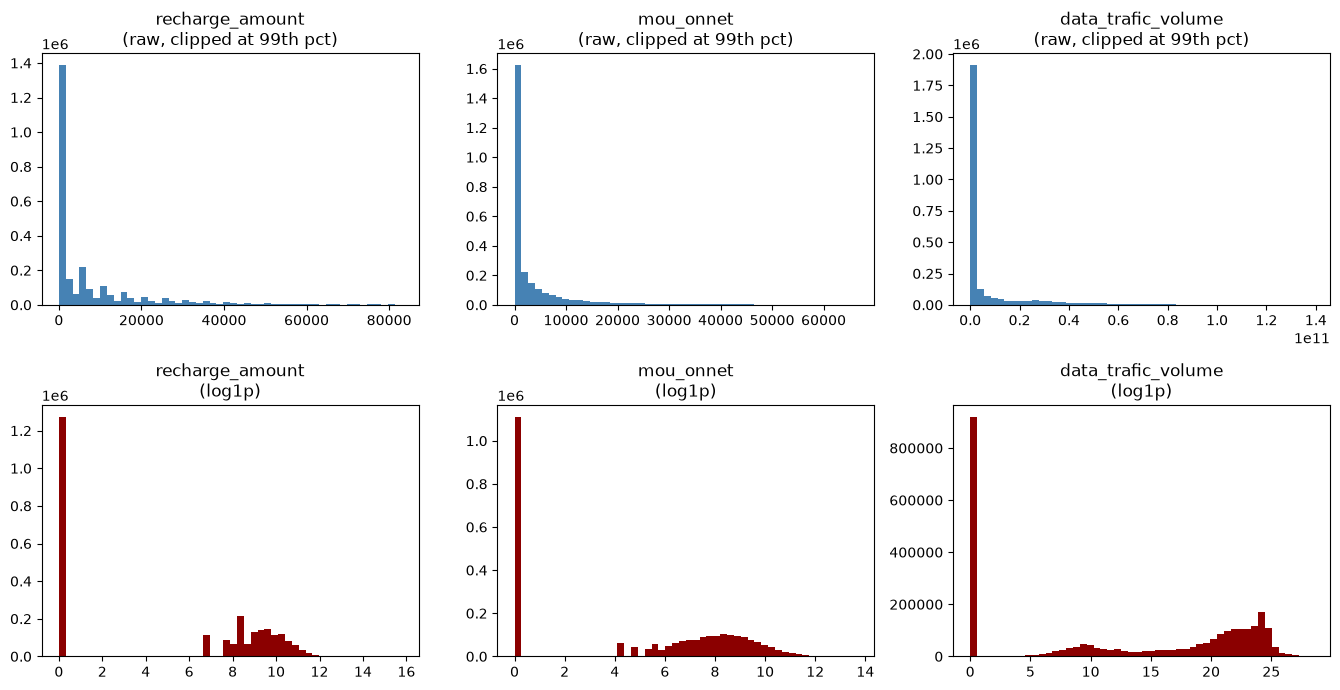

In [6]:
fig, axes = plt.subplots(2, len(log1p_cols), figsize=(4.5 * len(log1p_cols), 7))
for i, col in enumerate(log1p_cols):
    raw = monthly_usage[col]

    # "before" is clipped at the 99th percentile for display legibility only
    # (the skew stat above is computed on the full, unclipped column).
    axes[0, i].hist(raw, bins=50, range=(0, raw.quantile(0.99)), color="steelblue")
    axes[0, i].set_title(f"{col}\n(raw, clipped at 99th pct)")

    axes[1, i].hist(np.log1p(raw), bins=50, color="darkred")
    axes[1, i].set_title(f"{col}\n(log1p)")

plt.tight_layout()
save_fig(fig, "01_log1p_transformation")
plt.show()

**Observations — Distribution transformation check**

- **`log1p` sharply reduces skew for all three variables.** `recharge_amount` goes from extremely skewed (57.27) to essentially symmetric (0.00); `mou_onnet` goes from 9.60 to -0.06; `data_trafic_volume` goes from 11.94 to -0.16.
- **`recharge_amount` is the most extreme case** (skew 57.27 before transform) — consistent with the "many zero values, a few very heavy users" pattern already noted above.
- This confirms `log1p` is a reasonable, effective transform for these variables ahead of the aggregated feature engineering step, where it's actually applied.

## 2. Target analysis

In [7]:
from churn.eda.target_analysis import run_target_analysis

run_target_analysis(subscriber_static)


--- Overall churn rate ---
is_churn
False    387510
True      36256
Name: count, dtype: int64
churn rate: 8.56%

--- Churn rate by gender ---
        churn_rate  n_subscribers
gender                           
U         0.111111              9
F         0.100296          97312
M         0.098169         258401
NaN       0.016578          68044
  (Note: 1 group(s) below 100 subscribers — treat their churn rates as unreliable, not a real pattern.)

--- Churn rate by marital_status ---
                churn_rate  n_subscribers
marital_status                           
Celibataire       0.107447         278585
Marie             0.077977          45962
Veuf              0.068966             29
Divorce           0.031250             32
NaN               0.027592          99158
  (Note: 2 group(s) below 100 subscribers — treat their churn rates as unreliable, not a real pattern.)

--- Churn rate by customer_language ---
                   churn_rate  n_subscribers
customer_language          


--- Churn rate by age bucket (excluding 20683 null-age rows) ---
            churn_rate  n_subscribers
age_bucket                           
[0, 10)       0.047619             63
[10, 20)      0.141145           5923
[20, 30)      0.102047          74407
[30, 40)      0.092231          98069
[40, 50)      0.091676          94049
[50, 60)      0.078111          70886
[60, 70)      0.072876          43018
[70, 80)      0.079347          12502
[80, 90)      0.076923           3783
[90, 100)     0.081365            381

--- Churn rate by tenure (classe_anciennete) ---
                     churn_rate  n_subscribers
classe_anciennete                             
0 to 3 Months          0.000751          21303
3 to 6 Months          0.069978          41256
6 to 12 Months         0.178876          67952
12 to 36 Months        0.131871          89777
More than 36 Months    0.045995         203478



--- Churn rate by tenure (classe_anciennete) ---
                     churn_rate  n_subscribers
classe_anciennete                             
0 to 3 Months          0.000751          21303
3 to 6 Months          0.069978          41256
6 to 12 Months         0.178876          67952
12 to 36 Months        0.131871          89777
More than 36 Months    0.045995         203478


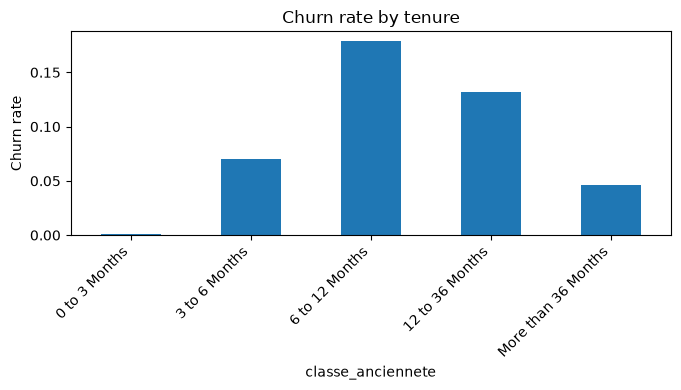


--- Churn rate by age bucket (excluding 20683 null-age rows) ---
            churn_rate  n_subscribers
age_bucket                           
[0, 10)       0.047619             63
[10, 20)      0.141145           5923
[20, 30)      0.102047          74407
[30, 40)      0.092231          98069
[40, 50)      0.091676          94049
[50, 60)      0.078111          70886
[60, 70)      0.072876          43018
[70, 80)      0.079347          12502
[80, 90)      0.076923           3783
[90, 100)     0.081365            381


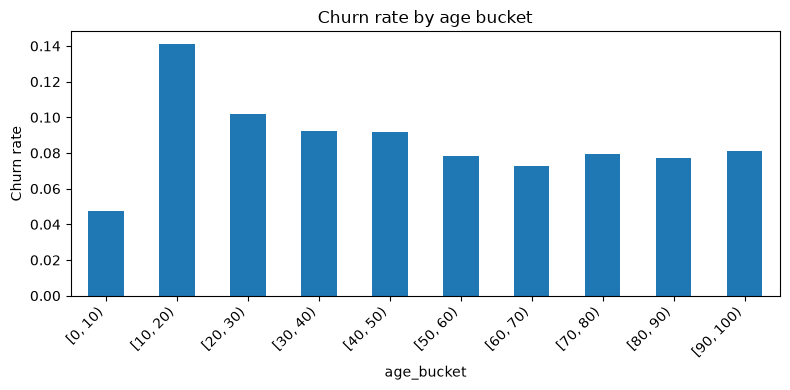

In [8]:
from churn.eda.target_analysis import churn_rate_by_tenure, churn_rate_by_age_bucket

tenure = churn_rate_by_tenure(subscriber_static)
fig = plt.figure(figsize=(7, 4))
tenure["churn_rate"].plot(kind="bar")
plt.ylabel("Churn rate")
plt.title("Churn rate by tenure")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
save_fig(fig, "02_churn_rate_by_tenure")
plt.show()

age = churn_rate_by_age_bucket(subscriber_static)
fig = plt.figure(figsize=(8, 4))
age["churn_rate"].plot(kind="bar")
plt.ylabel("Churn rate")
plt.title("Churn rate by age bucket")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
save_fig(fig, "02_churn_rate_by_age")
plt.show()


--- Churn rate by marital_status ---
                churn_rate  n_subscribers
marital_status                           
Celibataire       0.107447         278585
Marie             0.077977          45962
Veuf              0.068966             29
Divorce           0.031250             32
NaN               0.027592          99158
  (Note: 2 group(s) below 100 subscribers — treat their churn rates as unreliable, not a real pattern.)


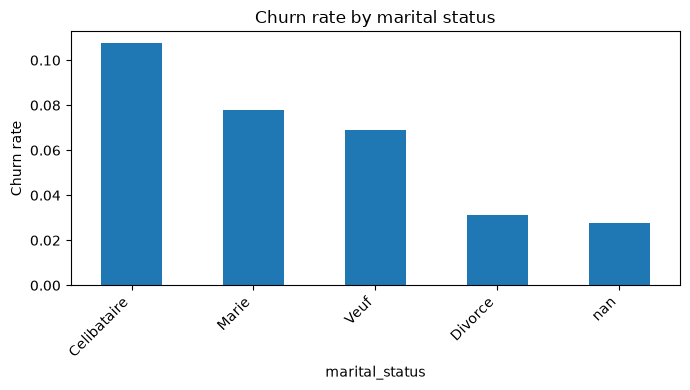


--- Churn rate by customer_language ---
                   churn_rate  n_subscribers
customer_language                           
Anglais              0.115042         235331
Arabe                0.053307          78901
Français             0.052783          62047
NaN                  0.035870          47393
Italien              0.021277             94
  (Note: 1 group(s) below 100 subscribers — treat their churn rates as unreliable, not a real pattern.)


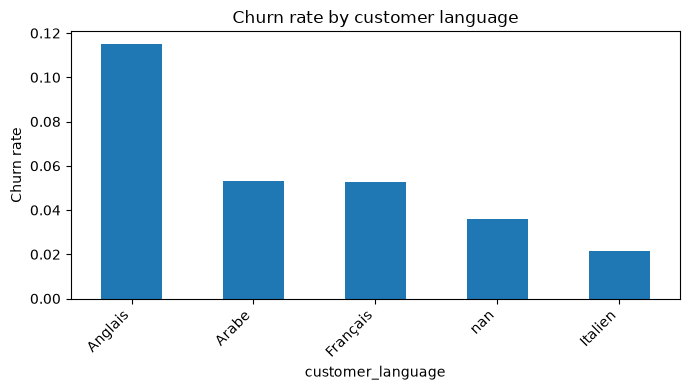

In [9]:
from churn.eda.target_analysis import churn_rate_by_demographic

marital = churn_rate_by_demographic(subscriber_static, "marital_status")
fig = plt.figure(figsize=(7, 4))
marital["churn_rate"].plot(kind="bar")
plt.ylabel("Churn rate")
plt.title("Churn rate by marital status")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
save_fig(fig, "02_churn_rate_by_marital_status")
plt.show()

language = churn_rate_by_demographic(subscriber_static, "customer_language")
fig = plt.figure(figsize=(7, 4))
language["churn_rate"].plot(kind="bar")
plt.ylabel("Churn rate")
plt.title("Churn rate by customer language")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
save_fig(fig, "02_churn_rate_by_customer_language")
plt.show()

**Observations — Target analysis**

- **Overall churn rate: 8.56%** (36,256 / 423,766)

- **Demographic variables show differences in churn across groups.**: For example, subscribers with customer_language = Anglais have a higher churn rate (~11.5%) than those with Arabe or Français (~5%).    
- **Marital status also shows a clear split.** Single subscribers churn at 10.7%, about 38% higher than married subscribers (7.8%). Divorced (3.1%) and widowed (6.9%) groups are both below the 100-subscriber reliability threshold, so their rates shouldn't be read as a real pattern.
- **Customer language, visualized:** Anglais's elevated churn rate (11.5%) stands out clearly against Arabe and Français (~5% each). The Italien group (n=94) falls below the reliability threshold despite its low observed rate (2.1%).
- **contact_city is not usable in its current form.** The extremely high number of distinct values indicates inconsistent text formatting (capitalization, spelling variations, extra spaces, etc.). A normalization step will be required before this variable can be used for analysis or feature engineering.  
- **Age shows a meaningful relationship with churn.** The highest churn rate is observed among subscribers aged 10–20 years (14.1%), declining fairly steadily through the 50s (down to 7.8% for ages 50–60); from age 60 onward it plateaus in the 7–8% range rather than continuing to decline. The 0–10 age group is too small to draw reliable conclusions.  
- **Tenure (classe_anciennete) is strongly associated with churn.** The churn rate peaks for subscribers with 6–12 months of tenure (17.9%) and then steadily decreases for longer-tenured customers. This confirms the pattern already identified during the raw data audit.

## 3. Temporal exploratory analysis

In [10]:
from churn.eda.temporal import run_temporal_analysis

run_temporal_analysis(monthly_usage, subscriber_static)


--- Timeline coverage ---
monthly_usage period_date range: 2024-07-01 00:00:00 -> 2025-01-01 00:00:00
unique periods: 7
date_activation range: 2002-12-26 00:00:00 -> 2025-02-19 18:15:17
churn_date range (churners only): 2024-08-15 00:00:00 -> 2025-03-15 00:00:00

--- Tenure distribution ---
                     n_subscribers    pct
classe_anciennete                        
0 to 3 Months                21303   5.03
3 to 6 Months                41256   9.74
6 to 12 Months               67952  16.04
12 to 36 Months              89777  21.19
More than 36 Months         203478  48.02



--- Exploratory inactivity vs reference_date=2025-01-01 00:00:00 ---
churn=True:
count    31794.000000
mean       200.435522
std        185.621431
min        -78.000000
10%         69.000000
25%        104.000000
50%        168.000000
75%        257.000000
90%        343.000000
max       3244.000000
Name: inactivity_days, dtype: float64

churn=False:
count    366620.000000
mean         -2.120618
std         244.614081
min         -78.000000
10%         -78.000000
25%         -78.000000
50%         -77.000000
75%         -18.000000
90%         106.000000
max        3322.000000
Name: inactivity_days, dtype: float64

--- Churn events by month (count of churn_date falling in that month) ---
churn_month
2024-08      151
2024-09      345
2024-10      427
2024-11      388
2024-12    16850
2025-01    18090
2025-02        1
2025-03        4
Freq: M, dtype: int64

--- churn_date concentration ---
total churners: 36256
distinct churn_date values: 201

top 15 exact dates by churner count:
churn_d

**How to read the chart below:** `inactivity_days` is computed against a single
fixed reference date — `monthly_usage`'s max `period_date` (2025-01-01). A
**negative** value means the subscriber's `last_call_date` is *after* the
reference date (i.e. they were still active past it); a **positive** value
means their last call was *before* the reference date, i.e. they'd already
gone dormant for that many days. This is an early, single-reference-date
exploratory check, not the final window justification — it's meant to
motivate the more rigorous per-customer `days_before_churn` analysis in
Section 4, which is what actually drives the observation-window decision.


--- Exploratory inactivity vs reference_date=2025-01-01 00:00:00 ---
churn=True:
count    31794.000000
mean       200.435522
std        185.621431
min        -78.000000
10%         69.000000
25%        104.000000
50%        168.000000
75%        257.000000
90%        343.000000
max       3244.000000
Name: inactivity_days, dtype: float64

churn=False:


count    366620.000000
mean         -2.120618
std         244.614081
min         -78.000000
10%         -78.000000
25%         -78.000000
50%         -77.000000
75%         -18.000000
90%         106.000000
max        3322.000000
Name: inactivity_days, dtype: float64


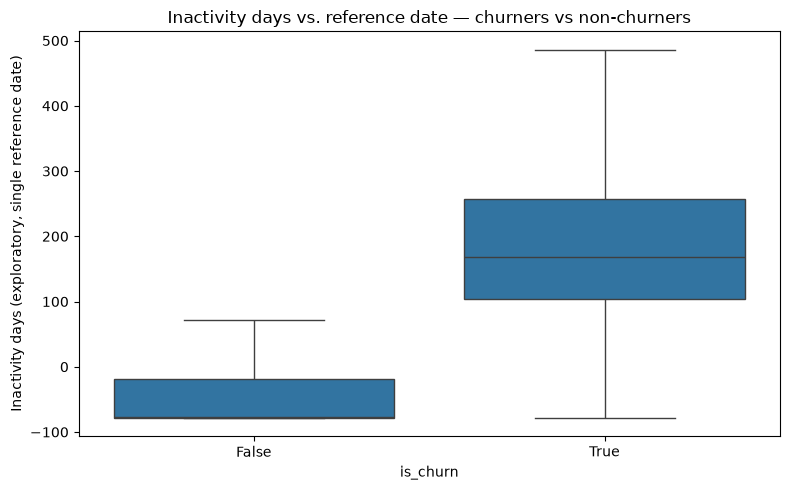

In [11]:
from churn.eda.temporal import explore_inactivity_vs_reference

reference_date = monthly_usage["period_date"].max()
inactivity = explore_inactivity_vs_reference(subscriber_static, reference_date)

fig = plt.figure(figsize=(8, 5))
sns.boxplot(data=inactivity, x="is_churn", y="inactivity_days", showfliers=False)
plt.title("Inactivity days vs. reference date — churners vs non-churners")
plt.xlabel("is_churn")
plt.ylabel("Inactivity days (exploratory, single reference date)")
plt.tight_layout()
save_fig(fig, "03_inactivity_by_churn")
plt.show()

**Observations — Temporal exploratory analysis**

- **The available usage history covers July 2024 to January 2025 (7 months).** However, `last_call_date` and `churn_date` extend to March 2025, meaning the target information is available beyond the monthly usage history. This provides a short observation period after the last available usage data.  
- **The subscriber base is mainly composed of long-term customers.** Nearly half of the subscribers (48%) have more than 36 months of tenure, while only 5% have been customers for less than 3 months.  
- **Churners generally show much longer inactivity periods than non-churners.** This suggests that recent customer activity is likely to be an informative predictor of churn. The negative inactivity values observed for many non-churners are expected because the chosen reference date precedes many of their recorded `last_call_date` values.  

## 4. Behavioral analysis for churners(prediction-window justification)

In [12]:
from churn.eda.behavioral import run_behavioral_analysis

results = run_behavioral_analysis(monthly_usage, subscriber_static)


--- Usage trend vs. days-before-churn (churners only, 15-day buckets) ---
        recharge_amount  number_of_recharges    mou_onnet  data_trafic_volume  \
bucket                                                                          
0              8.273254             0.001477    12.602529        1.654963e+08   
15            11.492829             0.004561    43.990164        6.508526e+08   
30            18.314149             0.006052    56.042138        3.637878e+09   
45            22.224111             0.008389   140.541444        1.629147e+09   
60            47.888161             0.014992   137.363260        5.624327e+09   
75            22.668468             0.007555    80.922190        1.588926e+09   
90           160.383853             0.120548   171.505625        4.866218e+09   
105          636.830218             0.601350   229.778553        1.364513e+09   
120          915.035870             0.862686   351.328283        3.885190e+09   
135          731.846807           


--- Usage by calendar month: churners vs non-churners ---
            recharge_amount              number_of_recharges            \
is_churn              False        True                False     True    
period_date                                                              
2024-07-01     11464.047118  2835.477690            5.568878  1.500997   
2024-08-01     11505.283065  1014.724071            5.549306  0.870260   
2024-09-01     10969.019765   636.508915            5.241830  0.594914   
2024-10-01      9884.882763   240.111307            5.018259  0.217894   
2024-11-01      8935.307873    17.944279            4.562727  0.005685   
2024-12-01      8931.519683    13.408006            4.431800  0.003449   
2025-01-01      8537.850549     8.531443            4.279206  0.002786   

               mou_onnet             data_trafic_volume                
is_churn           False       True               False         True   
period_date                                             

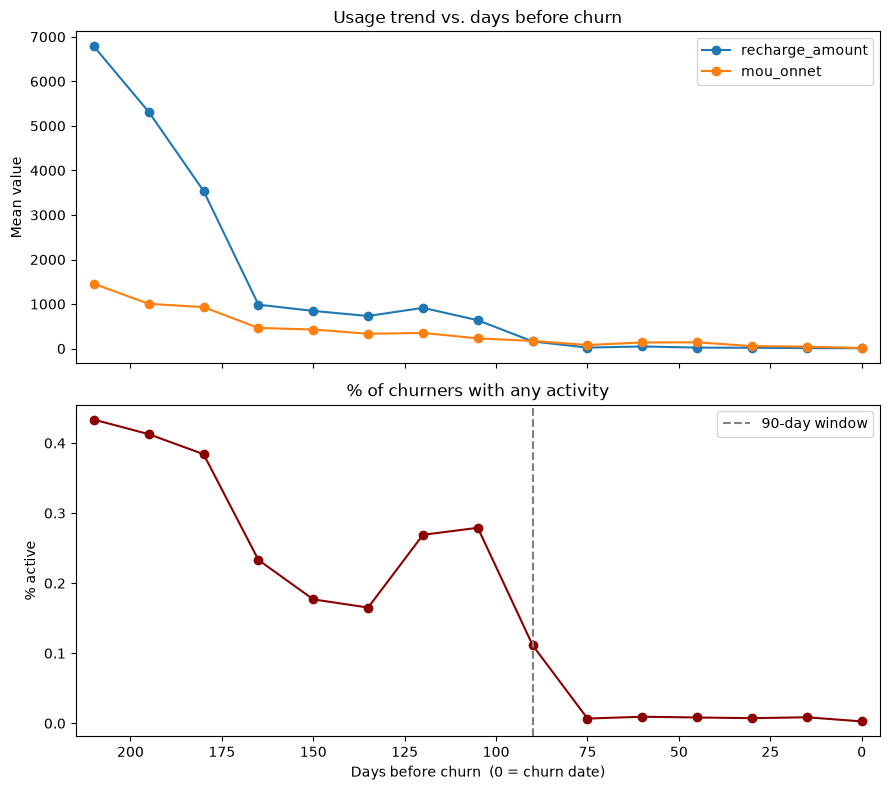

In [13]:
trend = results["trend"]
activity = results["activity_decline"]

fig, axes = plt.subplots(2, 1, figsize=(9, 8), sharex=True)

axes[0].plot(trend.index, trend["recharge_amount"], marker="o", label="recharge_amount")
axes[0].plot(trend.index, trend["mou_onnet"], marker="o", label="mou_onnet")
axes[0].set_ylabel("Mean value")
axes[0].set_title("Usage trend vs. days before churn")
axes[0].legend()

axes[1].plot(activity.index, activity["pct_active"], marker="o", color="darkred")
axes[1].axvline(90, color="gray", linestyle="--", label="90-day window")
axes[1].set_xlabel("Days before churn  (0 = churn date)")
axes[1].set_ylabel("% active")
axes[1].set_title("% of churners with any activity")
axes[1].legend()

max_bucket = trend.index.max()
for ax in axes:
    ax.set_xlim(max_bucket + 5, -5)  # explicit reversed range: high values on the left, 0 on the right

plt.tight_layout()
save_fig(fig, "04_behavioral_window_justification")
plt.show()

**Observations — Behavioral analysis before churn**

- **Customer activity declines progressively before churn,**
  then it drops sharply and then remains very low in the last 90 days. pct_active falls from ~41–43% (195–210 days before churn) to ~11–28% (90–135 days before), then stays below 1% during the final ~75 days.
- **A 90-day window** appears to provide a good balance between predictive signal and intervention time.

## 5. Feature relationships


--- Correlation matrix (16 numeric usage features) ---
                             recharge_amount  number_of_recharges  \
recharge_amount                         1.00                 0.70   
number_of_recharges                     0.70                 1.00   
number_of_sms_onnet                     0.23                 0.32   
number_of_sms_offnet                    0.06                 0.07   
number_of_sms_international             0.03                 0.01   
mou_onnet                               0.21                 0.23   
mou_offnet_mobile                       0.23                 0.24   
mou_offnet_fix                          0.04                 0.02   
mou_international                       0.04                 0.02   
consumption_revenue                     0.47                 0.42   
arpu_out_without_bonus                  0.69                 0.55   
incoming_revenue                        0.07                 0.09   
data_trafic_volume                      0.07   

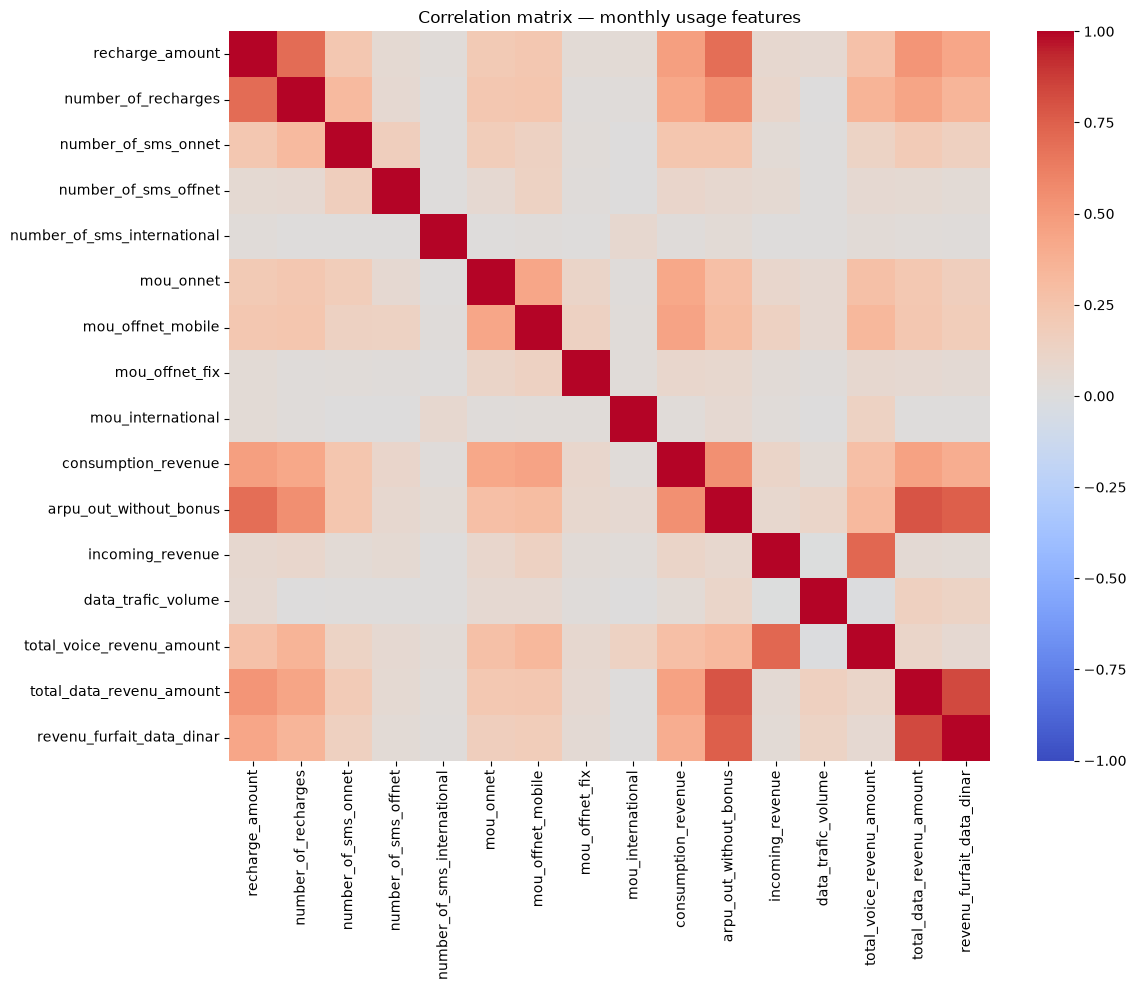

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt
from churn.eda.correlations import run_correlation_analysis

corr_results = run_correlation_analysis(monthly_usage)

fig=plt.figure(figsize=(12, 10))
sns.heatmap(corr_results["correlation_matrix"], annot=False, cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Correlation matrix — monthly usage features")
plt.tight_layout()
save_fig(fig, "05_correlation_heatmap")
plt.show()

**Observations — Feature relationships**  
- Only five feature pairs have a high correlation (|r| ≥ 0.7), and all are expected because they measure similar or related concepts:

  - Data revenue features (`revenu_furfait_data_dinar` and `total_data_revenu_amount`).  
  - ARPU with data revenue features.  
  - `incoming_revenue` with `total_voice_revenu_amount`.  
  - `number_of_recharges` with `recharge_amount`.    
- Most feature pairs have low correlation (|r| < 0.3), indicating that the dataset captures different aspects of customer behavior rather than containing many redundant variables.

## 6. Categorical association strength (Cramér's V)

A single summary number per categorical variable, to rank them against each
other directly — cross-checking the per-category churn-rate tables and
charts already shown in Section 2.


--- Cramér's V vs is_churn ---
                   cramers_v
feature                     
classe_anciennete     0.1954
customer_language     0.1192
marital_status        0.1190
gender                0.1079


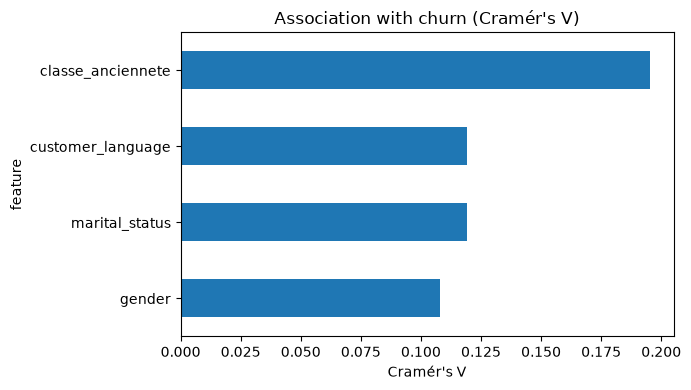

In [15]:
from churn.eda.association import compute_cramers_v_table

cramers_table = compute_cramers_v_table(subscriber_static)

fig = plt.figure(figsize=(7, 4))
cramers_table["cramers_v"].plot(kind="barh")
plt.xlabel("Cramér's V")
plt.title("Association with churn (Cramér's V)")
plt.gca().invert_yaxis()
plt.tight_layout()
save_fig(fig, "17_cramers_v_association")
plt.show()

**Observations — Categorical association (Cramér's V)**

- **`classe_anciennete` (tenure) has the strongest association with churn** (V = 0.195), clearly ahead of the other three. This matches Section 2, where tenure showed by far the widest spread in churn rate across its groups (0.08% to 17.9%).
- **`customer_language` (V = 0.119) and `marital_status` (V = 0.119) are essentially tied**, both moderately ahead of `gender`. This is consistent with Section 2, where both showed a clear split between their high- and low-churn groups (Anglais vs. Arabe/Français; single vs. married).
- **`gender` has the weakest association** (V = 0.108) of the four — consistent with Section 2's gender table, where the reliable groups (M, F) had close churn rates (9.8% vs. 10.0%).
- All four values are in the 0.10–0.20 range, i.e. weak-to-moderate by conventional Cramér's V benchmarks — none of these categoricals is a dominant single predictor on its own, which is consistent with churn here being driven by a combination of factors rather than any one variable.

## 7. PCA visualization

A 2D projection of the same numeric usage features from Section 5, aggregated
to one row per subscriber (mean across their observed months — fitting PCA
directly on the subscriber-month panel would let long-tenured subscribers'
repeated months dominate the projection), to check visually whether churners
and non-churners separate in a reduced feature space. Fit on the full
dataset (not train-only) — like the correlation heatmap, this is a
descriptive EDA visualization, not a modeling feature.


--- PCA on 16 numeric usage features, aggregated to 423755 subscribers (excluding 0 with missing values) ---
Variance explained: PC1=30.0%, PC2=11.2%, total=41.2%


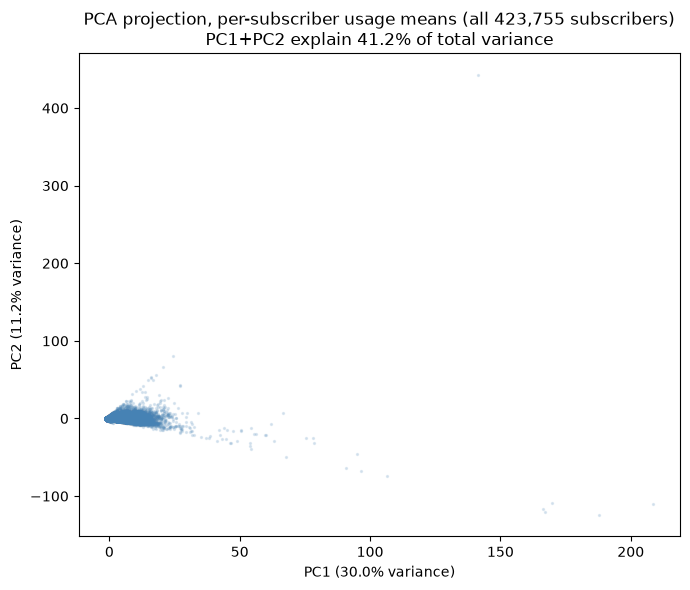

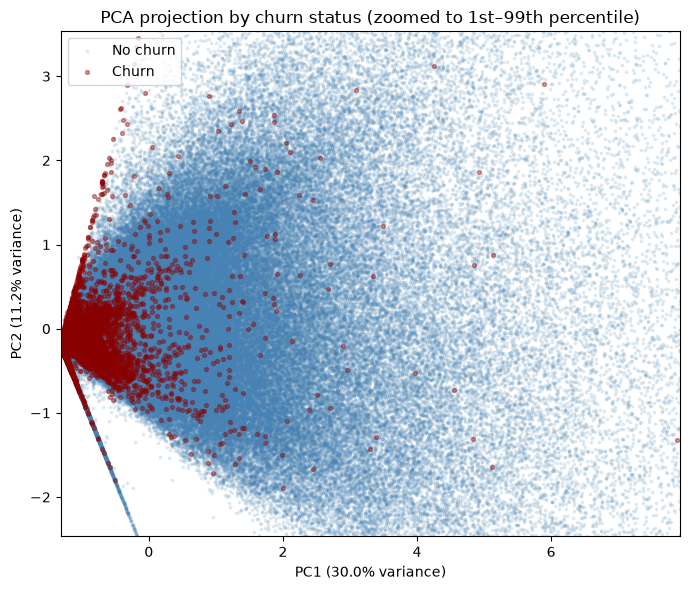

In [16]:
from churn.eda.correlations import compute_pca_projection

pca_df, explained_var = compute_pca_projection(monthly_usage)
pca_df = pca_df.merge(subscriber_static[["subscriber_id", "is_churn"]], on="subscriber_id", how="left")

# --- Plot A: general shape, no churn coloring, full (unclipped) axis range ---
# purpose is to show the data's natural spread, including any real outliers.
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(pca_df["PC1"], pca_df["PC2"], s=2, alpha=0.15, color="steelblue", rasterized=True)
ax.set_xlabel(f"PC1 ({explained_var[0]:.1f}% variance)")
ax.set_ylabel(f"PC2 ({explained_var[1]:.1f}% variance)")
ax.set_title(f"PCA projection, per-subscriber usage means (all {len(pca_df):,} subscribers)\n"
             f"PC1+PC2 explain {sum(explained_var):.1f}% of total variance")
plt.tight_layout()
save_fig(fig, "18a_pca_shape")
plt.show()

# --- Plot B: churn-colored, zoomed to the 1st-99th percentile of PC1/PC2 ---
# The axis limits below are VISUALIZATION ONLY -- they do not alter the PCA
# fit/projection above or drop any rows from pca_df, they only change what's
# visible in this one plot so the dense main cluster is legible.
x_lo, x_hi = pca_df["PC1"].quantile([0.01, 0.99])
y_lo, y_hi = pca_df["PC2"].quantile([0.01, 0.99])

non_churn = pca_df.loc[~pca_df["is_churn"]]
churn = pca_df.loc[pca_df["is_churn"]]

fig, ax = plt.subplots(figsize=(7, 6))
# Non-churn (majority class) plotted first, small/low-alpha; churn plotted
# on top, larger/more opaque, so the minority class isn't visually buried.
ax.scatter(non_churn["PC1"], non_churn["PC2"], s=3, alpha=0.12, color="steelblue", label="No churn", rasterized=True)
ax.scatter(churn["PC1"], churn["PC2"], s=8, alpha=0.4, color="darkred", label="Churn", rasterized=True)
ax.set_xlim(x_lo, x_hi)
ax.set_ylim(y_lo, y_hi)
ax.set_xlabel(f"PC1 ({explained_var[0]:.1f}% variance)")
ax.set_ylabel(f"PC2 ({explained_var[1]:.1f}% variance)")
ax.set_title("PCA projection by churn status (zoomed to 1st–99th percentile)")
ax.legend()
plt.tight_layout()
save_fig(fig, "18b_pca_by_churn")
plt.show()

**Observations — PCA visualization**

(aggregate to one row per subscriber, then apply StandardScaler, and only then fit PCA)  
- **PC1 and PC2 together explain 41.2%** of total variance (PC1 = 30.0%, PC2 = 11.2%) across the 16 numeric usage features, aggregated to one row per subscriber.  
- **Plot A** The first two principal components explain 41.2% of the total variation in subscriber usage. Most subscribers are concentrated in a relatively small area, while a few points are far from the main group, indicating unusual usage patterns/outliers. This shows that subscribers have different usage behaviors, but two dimensions alone cannot represent all of the variation in the data.  
- **Plot B** Churned and non-churned subscribers overlap heavily in the PCA space, with no clear separate cluster for churners. This means that the main usage patterns captured by the first two components do not by themselves clearly separate churners from non-churners. Churn prediction therefore requires combining several features and more complex relationships, which supports using models such as XGBoost and LightGBM rather than relying on PCA alone.  
- **Stated plainly:** churners are visibly lower-usage on average, but PCA on these aggregated features does not show clean visual separation between the two classes. That doesn't mean the underlying features aren't predictive — the tree-based models used later capture non-linear, multi-feature interactions that a 2D linear projection can't represent — it just means churn risk isn't something you can eyeball directly off a PCA plot here.

## EDA Summary

- **Overall churn rate: 8.56%**, with tenure and recent inactivity standing out as the strongest churn signals — both later confirmed by survival analysis.
- **Demographics matter, but weakly on their own.** Cramér's V ranks `classe_anciennete` (tenure, V = 0.195) as the strongest categorical predictor, followed by `customer_language` and `marital_status` (~0.12 each, essentially tied), with `gender` weakest (0.108). All four fall in a weak-to-moderate range — consistent with churn being driven by a combination of factors rather than any single demographic.
- **A 90-day observation window is justified**: churner activity collapses to near-zero in the final ~75–90 days before churn, while remaining meaningfully elevated further out.
- **Usage features are highly skewed** (heavy right skew, many zeros); `log1p` sharply reduces this (e.g. `recharge_amount` skew drops from 57.3 to ~0.0), motivating its use later in feature engineering.
- **Feature redundancy is limited:** only 5 of the 120 possible numeric feature pairs are highly correlated (|r| ≥ 0.7), and all are conceptually expected (e.g. data revenue variables with each other, ARPU with revenue).
- **PCA on the numeric usage features shows real but partial separation** between churners and non-churners — churners shift toward lower usage, but the two groups' ranges overlap substantially rather than forming distinct clusters, consistent with churn being gradual and multi-factor rather than a single sharp usage cliff.